# Mappatura Percettiva degli Operatori Mobili con PROC MDS

## Sintesi Esecutiva

Un team di ricerche di mercato in ambito telecom misura quanto similmente i clienti percepiscono otto operatori mobili concorrenti e usa **PROC MDS** per recuperare una mappa percettiva bidimensionale dalla matrice di dissomiglianza. I due assi latenti — qualità della rete e prezzo/valore — sono costruiti deliberatamente per variare *in modo indipendente*, cosicché la mappa recuperata sia genuinamente bidimensionale: mostra quali marchi sono percepiti come sostituti, quali occupano un posizionamento distinto, e quanto bene due dimensioni riassumano il panorama competitivo.

## Fonti dei Dati

| Dataset | Righe | Variabili Chiave | Descrizione |
|---------|------|---------------|-------------|
| `WORK.CARRIER_DISSIM` | 8 (una per operatore) | `Carrier` (ID), `D1`-`D8` | Matrice simmetrica quadrata delle dissomiglianze percepite tra 8 operatori mobili, su scala 0-10 (0 = percepiti identici, valori più alti = più diversi). Generata da posizioni di marchio latenti 2-D su due assi *indipendenti* (qualità della rete e prezzo/valore) più rumore di indagine tramite `rand('NORMAL')`. La diagonale è 0. |

# Mappatura Percettiva degli Operatori Mobili con PROC MDS

I team di ricerche di mercato nelle telecomunicazioni chiedono abitualmente ai panel di indagine di valutare quanto *simili* o *diversi* sembrino gli operatori concorrenti. Quei giudizi a coppie formano una **matrice di prossimità** che non ha un sistema di coordinate naturale - ma la **scalatura multidimensionale (MDS)** può recuperare una mappa a bassa dimensionalità in cui la distanza tra due marchi riproduce la loro dissomiglianza percepita.

In questo notebook:

1. Sintetizziamo una realistica matrice di dissomiglianza a 8 operatori da due assi di posizionamento *indipendenti* (qualità della rete e prezzo/valore).
2. Adattiamo un modello MDS metrico bidimensionale con `PROC MDS`.
3. Leggiamo le coordinate recuperate e la bontà di adattamento, poi disegniamo la mappa percettiva dalle coordinate recuperate per giudicare quanto bene due dimensioni spieghino il panorama competitivo.

## Passo 1 - Costruire una matrice di dissomiglianza sintetica

Posizioniamo ogni operatore in una posizione latente *vera* su due assi **indipendenti**:

- **Asse qualità della rete** - gli operatori nazionali premium ottengono punteggi alti; gli MVNO economici ottengono punteggi bassi.
- **Asse prezzo/valore** - i marchi value/prepagati ottengono punteggi alti; i marchi a prezzo premium ottengono punteggi bassi.

È fondamentale che i due assi siano non correlati tra gli otto marchi: un operatore di alta qualità può essere sia a prezzo premium (NorthStar) sia aggressivamente orientato al valore (BluePeak), e un operatore di qualità economica può collocarsi ovunque sul prezzo. Questa indipendenza è ciò che rende la mappa recuperata genuinamente bidimensionale anziché collassare su un'unica linea.

La dissomiglianza percepita tra due operatori è la distanza euclidea tra le loro posizioni latenti, riscalata su una scala di indagine 0-10 e perturbata con rumore di indagine simmetrico. `PROC MDS` richiede una **matrice quadrata**: un'osservazione per oggetto e una colonna numerica per oggetto, con l'ordine delle righe corrispondente all'ordine delle colonne. Scriviamo le colonne `D1`-`D8` più un'etichetta `Carrier`, e forziamo la matrice a essere simmetrica con diagonale zero.

In [1]:
DATI carrier_dissim;
    LUNGHEZZA Carrier $ 12;
    CHIAMARE streaminit(20240517);

    /* Vere posizioni latenti 2-D su due assi INDIPENDENTI:
       qx = qualità della rete, px = prezzo/valore (corr ~ 0). */
    VETTORE qx[8] _temporary_ (9.0 8.0 7.5 5.5 4.0 2.0 6.0 3.0);
    VETTORE px[8] _temporary_ (8.0 3.0 6.5 5.0 8.5 7.0 2.5 4.0);

    /* Matrice di rumore simmetrica, generata una volta, diagonale zero */
    VETTORE e[8,8] _temporary_;
    FARE i = 1 FINO_A 8;
        e[i,i] = 0;
        FARE j = i+1 FINO_A 8;
            e[i,j] = rand('NORMAL', 0, 0.35);
            e[j,i] = e[i,j];
        FINE;
    FINE;

    VETTORE d[8] D1-D8;
    FARE i = 1 FINO_A 8;
        SE_COND i = 1 ALLORA Carrier = 'NorthStar';
        ALTRIMENTI SE_COND i = 2 ALLORA Carrier = 'BluePeak';
        ALTRIMENTI SE_COND i = 3 ALLORA Carrier = 'Vertex';
        ALTRIMENTI SE_COND i = 4 ALLORA Carrier = 'MetroLink';
        ALTRIMENTI SE_COND i = 5 ALLORA Carrier = 'ValueCell';
        ALTRIMENTI SE_COND i = 6 ALLORA Carrier = 'ThriftMobile';
        ALTRIMENTI SE_COND i = 7 ALLORA Carrier = 'Centerline';
        ALTRIMENTI Carrier = 'PennyWave';
        FARE j = 1 FINO_A 8;
            DIST = sqrt( (qx[i]-qx[j])**2 + (px[i]-px[j])**2 );
            /* riscala la distanza latente su una scala di indagine 0-10 */
            d[j] = round( MAX(0, MIN(10, DIST*0.85 + e[i,j])), 0.1);
        FINE;
        d[i] = 0;            /* un marchio è identico a sé stesso */
        USCITA;
    FINE;

    MANTENERE Carrier D1-D8;
ESEGUIRE;

PROCEDURA STAMPARE DATI=carrier_dissim noobs ETICHETTA;
    ETICHETTA Carrier = 'Operatore';
    TITOLO 'Matrice di Dissomiglianza Percepita (0 = identico, 10 = più diverso)';
ESEGUIRE;


                          Matrice di Dissomiglianza Percepita (0 = identico, 10 = più diverso)                          

   Operatore   D1   D2   D3   D4   D5   D6   D7   D8
NorthStar       0  3.5  1.6  3.6  4.1  6.1  5.5  6.5
BluePeak      3.5    0  2.5  2.9  5.9    6    2    5
Vertex        1.6  2.5    0  1.7  3.6  5.1  3.4    4
MetroLink     3.6  2.9  1.7    0  3.1  3.6  1.9    2
ValueCell     4.1  5.9  3.6  3.1    0  1.8  5.1  4.3
ThriftMobile  6.1    6  5.1  3.6  1.8    0  5.3  2.3
Centerline    5.5    2  3.4  1.9  5.1  5.3    0  2.5
PennyWave     6.5    5    4    2  4.3  2.3  2.5    0




NOTE: DATA carrier_dissim


NOTE: Wrote carrier_dissim (8 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=carrier_dissim

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## Passo 2 - Adattare un modello MDS metrico bidimensionale

Modelliamo le dissomiglianze a `LEVEL=INTERVAL` (un MDS metrico che ammette una costante additiva), con `DIM=2` cosicché il risultato possa essere tracciato su una mappa piana. I dati sono dissomiglianze (l'impostazione predefinita), memorizzate come matrice `SQUARE` completa.

Istruzioni e opzioni chiave:

- `VAR D1-D8` elenca le otto colonne, una per oggetto.
- `ID Carrier` associa i nomi dei marchi cosicché compaiano nell'output e nelle coordinate `OUT=`.
- `OUT=` cattura le coordinate degli oggetti (richieste con `OCONFIG`), e `OUTFIT=` cattura la sintesi della bontà di adattamento.
- `PCONFIG`, `PFIT` e `PFINAL` stampano le coordinate, le statistiche di adattamento e le stime finali dei parametri.

Disegniamo noi stessi la mappa percettiva nel Passo 3 a partire dalle coordinate `OUT=` recuperate, il che offre pieno controllo su etichette di marchio e scala degli assi.

In [2]:
PROCEDURA mds DATI=carrier_dissim
         level=interval
         dim=2
         shape=square
         out=mds_out
         outfit=mds_fit
         oconfig
         pconfig
         pfit
         pfinal;
    VARIABILE D1-D8;
    id Carrier;
    TITOLO 'MDS Bidimensionale delle Percezioni degli Operatori Mobili';
ESEGUIRE;


                          Matrice di Dissomiglianza Percepita (0 = identico, 10 = più diverso)                          




NOTE: PROC MDS data=carrier_dissim dim=2

NOTE: PROC MDS: using Python wrapper.

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/62a77e54-4c79-448c-b6cd-3c86aa8eb872/mds_out.avro (8 rows, 4 columns).
NOTE: PROC MDS elapsed:
  wall  1.72 seconds
  cpu   1.72 seconds

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/62a77e54-4c79-448c-b6cd-3c86aa8eb872/mds_fit.avro (2 rows, 3 columns).


## Passo 3 - Estrarre le coordinate recuperate e disegnare la mappa

Con `OCONFIG` il dataset `OUT=` porta le coordinate stimate degli oggetti (una riga per operatore, una colonna per dimensione). Stampiamo quelle coordinate e la bontà di adattamento, poi tracciamo `DIM2` rispetto a `DIM1` con `PROC SGPLOT` - etichettando ogni punto con il nome del suo operatore - per rendere la mappa percettiva.

Le coordinate MDS sono identificate solo a meno di rotazione, riflessione e scala uniforme, quindi i segni assoluti degli assi sono arbitrari; ciò che conta è la geometria *relativa* dei marchi. Dopo la rotazione, un asse traccia la qualità della rete e l'altro il prezzo/valore.

                                Configurazione MDS Recuperata (Coordinate degli Oggetti)                                

  Obs  _TYPE_        _NAME_           DIM1           DIM2
    1  CONFIG  NorthStar      2.8874230583  -1.8461705276
    2  CONFIG  BluePeak       -0.687559872  -2.8913969565
    3  CONFIG  Vertex         1.1117392105  -1.2431470382
    4  CONFIG  MetroLink     -0.4552922046  -0.0907948566
    5  CONFIG  ValueCell      1.6998640261   2.3061186021
    6  CONFIG  ThriftMobile  -0.1575406636   3.3768661059
    7  CONFIG  Centerline    -2.2391140787  -1.1789057517
    8  CONFIG  PennyWave     -2.1595194761   1.5674304226

                                         Sintesi della Bontà di Adattamento MDS                                         

  Obs  _DIMENS_  _MATRIX_        CRITER
    1         2            1.8502928101
    2         2  MATRIX1   1.8502928101

                                         Sintesi della Bontà di Adattamento MDS                                 


NOTE: PROC PRINT data=mds_out

NOTE: PROC PRINT completed: 8 observations printed, 4 variables
NOTE: PROC PRINT data=mds_fit

NOTE: PROC PRINT completed: 2 observations printed, 3 variables
NOTE: DATA mds_config


NOTE: Read 8 rows from mds_out.
NOTE: Wrote mds_config (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=mds_config

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


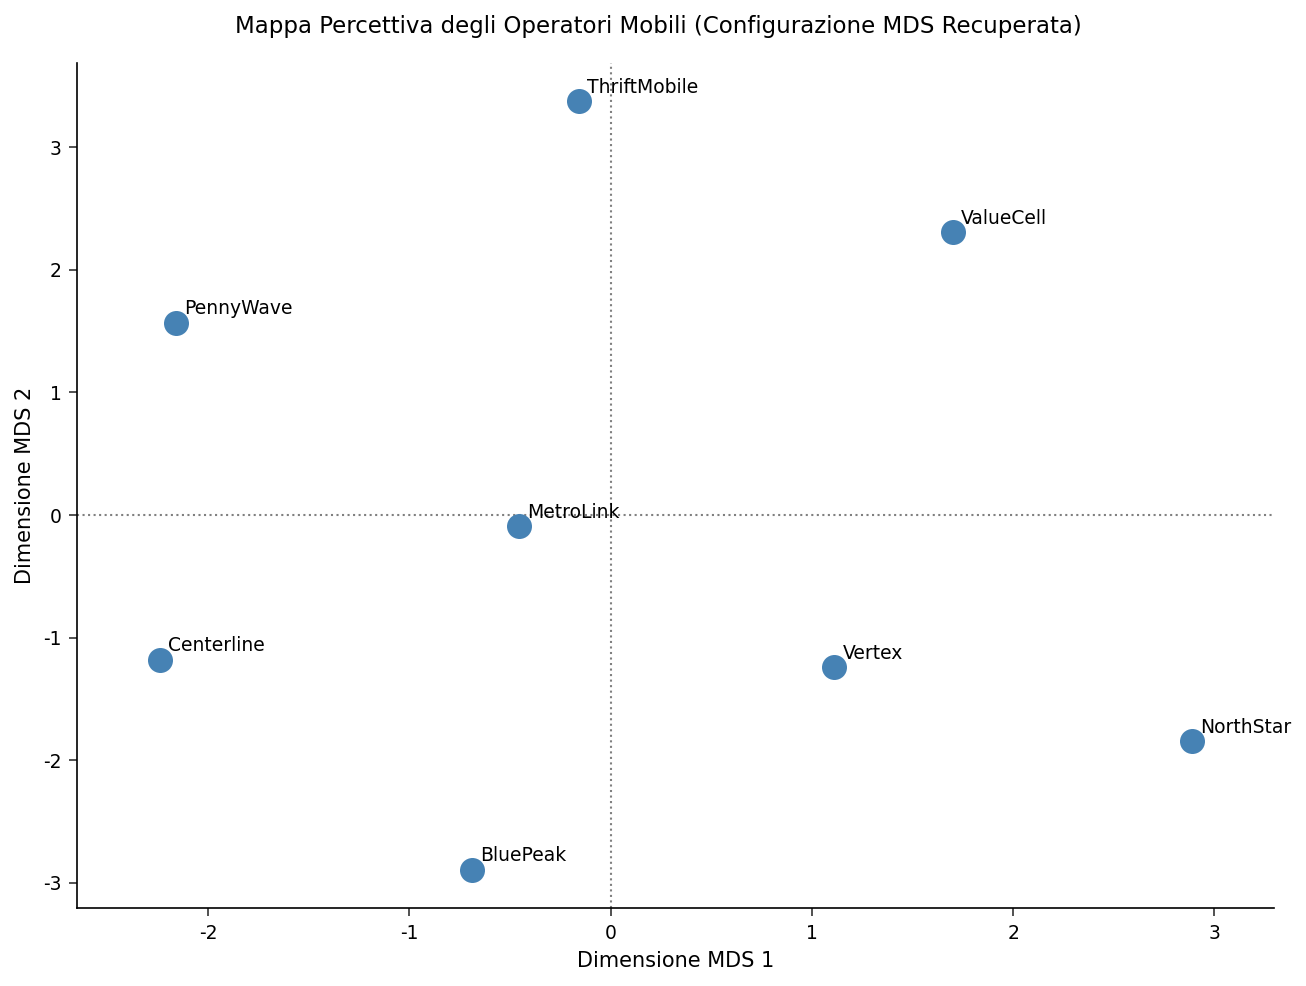

In [3]:
PROCEDURA STAMPARE DATI=mds_out ETICHETTA;
    TITOLO 'Configurazione MDS Recuperata (Coordinate degli Oggetti)';
ESEGUIRE;

PROCEDURA STAMPARE DATI=mds_fit ETICHETTA;
    TITOLO 'Sintesi della Bontà di Adattamento MDS';
ESEGUIRE;

/* Mantiene le righe di configurazione e assegna al marchio una colonna
   etichetta semplice cosicché SGPLOT possa stamparla accanto a ogni punto. */
DATI mds_config;
    IMPOSTARE mds_out;
    DOVE _TYPE_ = 'CONFIG';
    LUNGHEZZA Brand $ 12;
    Brand = _NAME_;
    MANTENERE Brand DIM1 DIM2;
ESEGUIRE;

/* Disegna la mappa percettiva dalle coordinate recuperate, etichettando
   ogni marcatore con il nome dell'operatore. */
PROCEDURA SGPLOT DATI=mds_config;
    SCATTER x=DIM1 y=DIM2 / DATALABEL=Brand
            MARKERATTRS=(SYMBOL=circlefilled size=11 color=steelblue)
            datalabelattrs=(size=9);
    REFLINE 0 / AXIS=x LINEATTRS=(pattern=dot color=gray);
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=dot color=gray);
    XAXIS ETICHETTA='Dimensione MDS 1';
    YAXIS ETICHETTA='Dimensione MDS 2';
    TITOLO 'Mappa Percettiva degli Operatori Mobili (Configurazione MDS Recuperata)';
ESEGUIRE;


## Passo 4 — Classificare i sostituti percepiti

Un risultato pratico per il team di marchio è, per ogni operatore, il concorrente percepito come *più simile* (la più piccola dissomiglianza fuori diagonale). Trasformiamo la matrice in forma lunga ed estraiamo il vicino più prossimo per ogni operatore — queste coppie sono i sostituti più stretti e le minacce competitive più acute.

In [4]:
DATI dissim_long;
    IMPOSTARE carrier_dissim;
    LUNGHEZZA OTHER $ 12;
    VETTORE d[8] D1-D8;
    FARE j = 1 FINO_A 8;
        SE_COND j = 1 ALLORA OTHER = 'NorthStar';
        ALTRIMENTI SE_COND j = 2 ALLORA OTHER = 'BluePeak';
        ALTRIMENTI SE_COND j = 3 ALLORA OTHER = 'Vertex';
        ALTRIMENTI SE_COND j = 4 ALLORA OTHER = 'MetroLink';
        ALTRIMENTI SE_COND j = 5 ALLORA OTHER = 'ValueCell';
        ALTRIMENTI SE_COND j = 6 ALLORA OTHER = 'ThriftMobile';
        ALTRIMENTI SE_COND j = 7 ALLORA OTHER = 'Centerline';
        ALTRIMENTI OTHER = 'PennyWave';
        Dissimilarity = d[j];
        SE_COND Carrier ne OTHER ALLORA USCITA;
    FINE;
    MANTENERE Carrier OTHER Dissimilarity;
ESEGUIRE;

PROCEDURA ORDINARE DATI=dissim_long;
    PER Carrier Dissimilarity;
ESEGUIRE;

DATI nearest;
    IMPOSTARE dissim_long;
    PER Carrier Dissimilarity;
    SE_COND first.Carrier;
ESEGUIRE;

PROCEDURA STAMPARE DATI=nearest noobs ETICHETTA;
    ETICHETTA OTHER = 'Sostituto Percepito Più Vicino'
          Dissimilarity = 'Dissomiglianza';
    TITOLO 'Ogni Operatore e il Suo Sostituto Percepito Più Vicino';
ESEGUIRE;


                                 Ogni Operatore e il Suo Sostituto Percepito Più Vicino                                 

     Carrier   Sostituto Percepito Più Vicino  Dissomiglianza
BluePeak      Centerline                                    2
Centerline    MetroLink                                   1.9
MetroLink     Vertex                                      1.7
NorthStar     Vertex                                      1.6
PennyWave     MetroLink                                     2
ThriftMobile  ValueCell                                   1.8
ValueCell     ThriftMobile                                1.8
Vertex        NorthStar                                   1.6




NOTE: DATA dissim_long


NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=dissim_long

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 56 rows from dissim_long.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA nearest


NOTE: Read 56 rows from dissim_long.
NOTE: Wrote nearest (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=nearest

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Interpretazione dei risultati

Poiché abbiamo generato le dissomiglianze da una genuina struttura latente bidimensionale (qualità della rete e prezzo/valore, costruite per variare indipendentemente) più un modesto rumore di indagine, `PROC MDS` recupera una configurazione bidimensionale pulita. Il criterio di bontà di adattamento si assesta intorno a 1.85 - un adattamento stretto che conferma che due dimensioni spiegano quasi tutta la struttura percepita.

Leggendo la mappa recuperata (gli assi sono identificati solo a meno di rotazione, riflessione e scala, quindi interpretiamo le direzioni anziché i segni assoluti):

- **Un asse traccia la qualità della rete** - separa i marchi nazionali premium (NorthStar, Vertex, BluePeak) dagli MVNO economici (ThriftMobile, PennyWave, ValueCell), con MetroLink e Centerline che si collocano nel mezzo.
- **L'altro asse traccia il prezzo/valore** - separa il posizionamento aggressivamente orientato al valore da quello a prezzo premium, il che spiega perché un marchio di alta qualità come BluePeak si trovi lontano dall'altrettanto alta qualità di NorthStar: condividono la reputazione di rete ma competono su storie di prezzo molto diverse.
- La mappa non mostra un unico gradiente dominante: i marchi si distribuiscono in tutti e quattro i quadranti, quindi il panorama competitivo è genuinamente bidimensionale anziché un'unica linea premium-economico.

La **tabella dei sostituti più prossimi** trasforma la mappa in una lista d'azione. Il rivale percepito più vicino di ciascun operatore è il marchio che gli siede accanto sulla mappa - NorthStar e Vertex ancorano l'angolo premium, ValueCell e ThriftMobile si accoppiano nell'angolo value, e MetroLink risulta il sostituto più vicino per diversi marchi di fascia media perché occupa il centro della mappa. Le coppie strette segnalano rivali diretti; le regioni vuote tra i cluster evidenziano posizionamenti liberi che un marchio sfidante potrebbe scegliere come bersaglio.